# Palette optimization for publication-quality single-cell & spatial plots

Color is not just an aesthetic choice—it directly affects how clearly readers can distinguish neighboring categories (cell types, clusters, domains) in *dense* visualizations. In spatially resolved transcriptomics (SRT), default categorical palettes and lexicographical (alphabetical) color assignment often place **similar colors on spatially adjacent or interlaced cell types**, creating perceptual ambiguity.

In this tutorial notebook we demonstrate how to improve categorical colorization using **Spaco** (Jing *et al.*, *Patterns* 2024), a spatially aware colorization framework that:

1. **Models spatial relationships between clusters** using the *Degree of Interlacement (DOI)* metric and a cluster interlacement graph (CI-graph).
2. **Selects a palette** either (i) automatically from the CI-graph embedding (graph-guided) or (ii) from a reference image (image-guided).
3. **Assigns colors to clusters** by matching the CI-graph to a color-difference graph (CD-graph), so that strongly interlaced/neighboring clusters receive more contrasting colors.

### Learning goals
By the end of this notebook you will be able to:

- Preview and combine OmicVerse categorical palettes for UMAP and spatial plots.
- Optimize *only* the **cluster→color mapping** while keeping a given palette fixed.
- Automatically generate a palette and mapping using Spaco (CI-graph guided).
- Extract a publication-style “theme palette” from an image and apply it to your data.
- Understand key parameters (`radius`, `n_neighbors`) and when to tune them.

> Reference: Jing, Z. *et al.* (2024) *Spaco: A comprehensive tool for coloring spatial data at single-cell resolution*. *Patterns* 5:100915.


In [15]:
import scanpy as sc
import omicverse as ov
from omicverse.external import spaco 
ov.style()

# Enable auto-reload for development
%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available
✅ plot_set complete.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Setup

We use **OmicVerse** for plotting and its `external.spaco` wrapper to access Spaco.  
The code cells below are kept minimal on purpose; the tutorial emphasis is on *what each step accomplishes* and *why it matches the method described in the Spaco paper*.

**Inputs needed by Spaco**
- `cell_coordinates`: a 2D coordinate matrix (e.g., `X_umap` or `spatial`)
- `cell_labels`: categorical labels for each cell/spot
- Optional: a fixed `palette` (to only optimize the assignment), or `image_palette` (to extract theme colors)

**Key parameters**
- `n_neighbors`: k in the spatial kNN graph used to compute DOI (paper default k≈30).
- `radius`: a distance scale used in the “dual-outlier-free” neighbor refinement; it must match the units of `cell_coordinates`.
  - For **spatial** coordinates (µm), a typical starting point is ~50 µm.
  - For **UMAP** coordinates (dimensionless), start with ~0.05–0.2 and adjust if results look over/under-smoothed.



In [2]:
adata=ov.datasets.pbmc8k()

🩸 Downloading PBMC 8k dataset
Using Stanford mirror for pbmc8k
⚠️ File ./data/pbmc8k.h5ad already exists
 Loading data from ./data/pbmc8k.h5ad
✅ Successfully loaded: 7750 cells × 20939 genes


In [11]:
sdata=ov.datasets.seqfish()

🐟 Downloading SeqFish dataset
Using Stanford mirror for seqfish
🔍 Downloading data to ./data/seqfish.h5ad...


Downloading: |                                     | 32.2M/0.00 [00:01<00:00, 25.2MB/s]


✅ Download completed
 Loading data from ./data/seqfish.h5ad
✅ Successfully loaded: 19416 cells × 351 genes


## Example datasets

We load:
- **PBMC8k** (single-cell RNA-seq) and visualize cell types on **UMAP**.
- **seqFISH** (spatial) and visualize cell types on **tissue coordinates**.

Although Spaco is designed for spatial coordinates, the same idea applies to any embedding where “neighbors” are meaningful. Here we use UMAP as a simple demonstration of neighborhood-aware color assignment, and `obsm['spatial']` for the true spatial case.


## 1) Prepare and preview palettes

OmicVerse provides a set of ready-to-use categorical palettes, e.g. `sc_color`, `red_color`, `green_color`, `orange_color`, `blue_color`, `purple_color`.

In practice, you may want to:
- Start from a default qualitative palette for *quick exploration*.
- Manually compose a palette (e.g., mixing a few distinct hues) for *small numbers of clusters*.
- When you have many clusters or strong spatial mixing, keep a broad palette but **optimize the cluster→color assignment** with Spaco.

Below we preview:
1. The default `sc_color` on UMAP and spatial plots.
2. A manually composed palette (by concatenating several base palettes).



X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


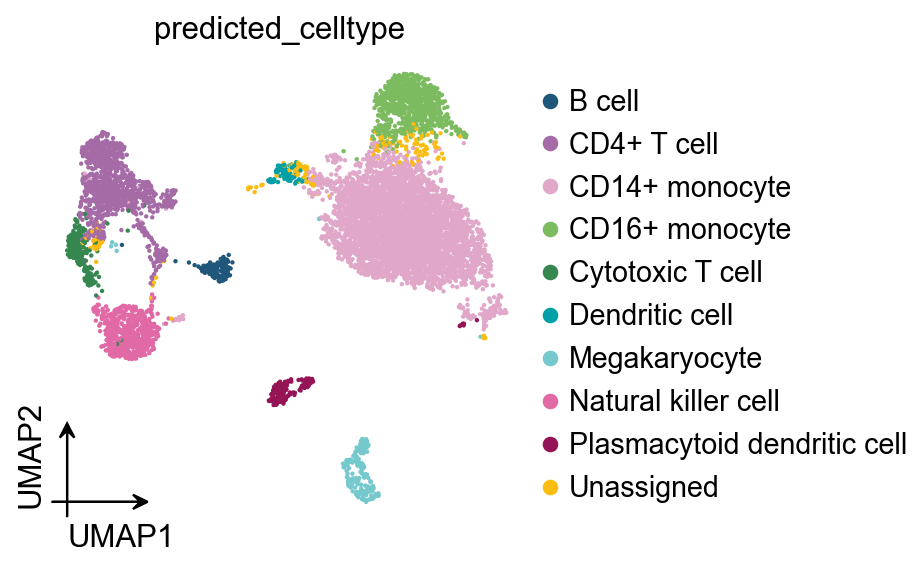

(<Figure size 2240x80 with 1 Axes>, <Axes: >)

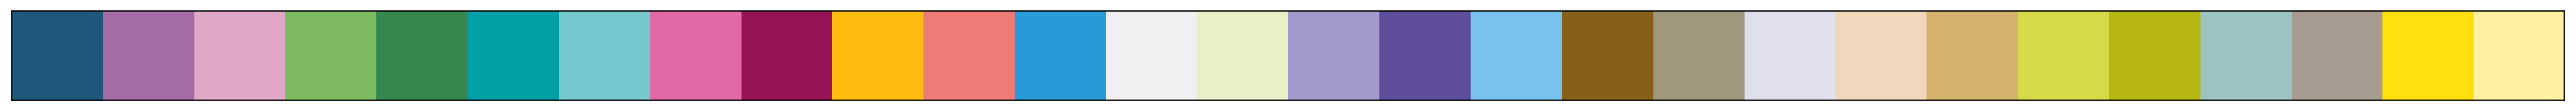

In [16]:
ov.pl.umap(
    adata,
    color=['predicted_celltype'],
    frameon='small',
    palette=ov.pl.sc_color
)
ov.pl.palplot(ov.pl.sc_color)

### Apply the same palette to a spatial plot

The goal is *consistency*: once you decide a palette style, you typically want it to work across both embedding plots (UMAP) and tissue plots. The next cell applies `sc_color` to a spatial embedding and visualizes the palette as a color strip.


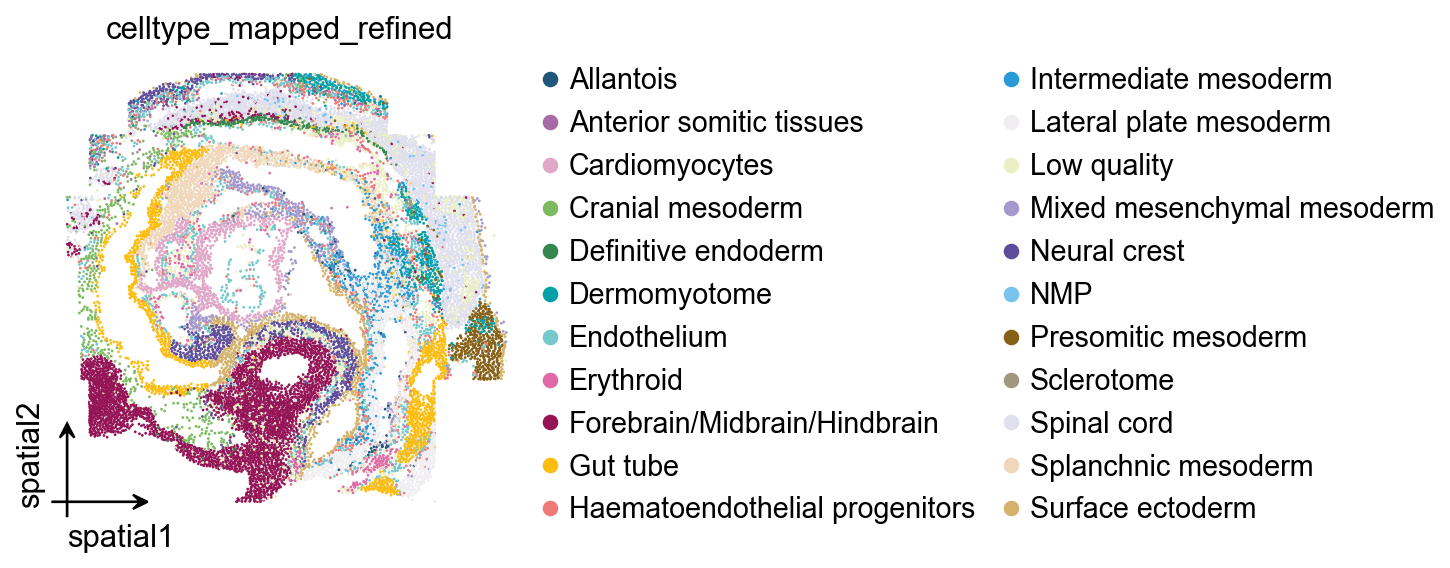

(<Figure size 2240x80 with 1 Axes>, <Axes: >)

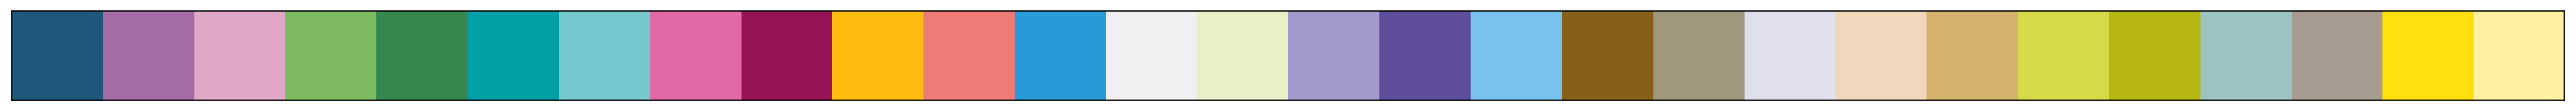

In [29]:
ov.pl.embedding(
    sdata,
    basis='spatial',
    color=['celltype_mapped_refined'],
    frameon='small',
    palette=ov.pl.sc_color
)
ov.pl.palplot(ov.pl.sc_color)

### Manual palette composition (when you want full control)

For a small set of categories (e.g., <10–20), manually combining a few high-contrast colors can be enough.

In the next cell we build a custom palette by concatenating subsets of OmicVerse palettes, then apply it to the UMAP plot.


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


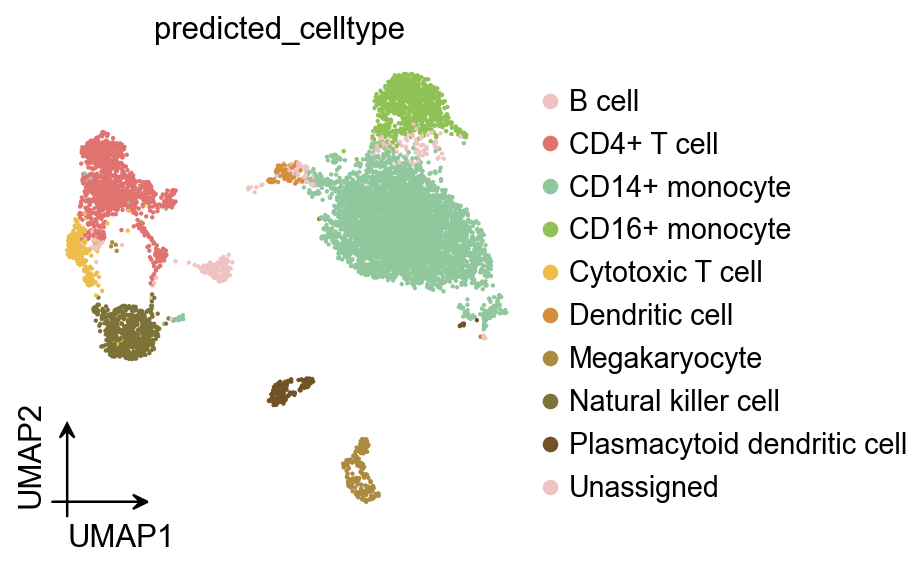

(<Figure size 720x80 with 1 Axes>, <Axes: >)

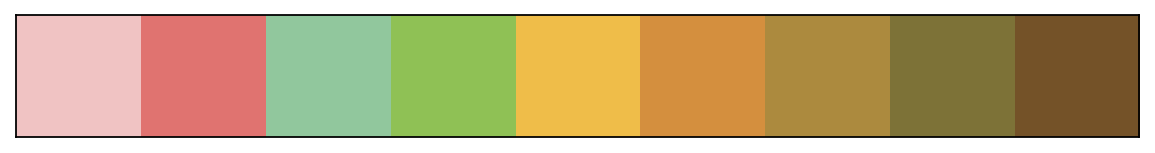

In [10]:
ov.pl.umap(
    adata,
    color=['predicted_celltype'],
    frameon='small',
    palette=ov.pl.red_color[:2]+ov.pl.green_color[:2]+ov.pl.orange_color[:5]
)
ov.pl.palplot(ov.pl.red_color[:2]+ov.pl.green_color[:2]+ov.pl.orange_color[:5])

## 2) Optimize color assignment with a **given** palette

Sometimes you already have a palette you want to keep (lab conventions, previous figures, journal theme), but you want to **reorder which cluster gets which color** so that neighboring/interlaced clusters become easier to distinguish.

Spaco (Jing *et al.*, *Patterns* 2024) does this by:

1. Building a **cluster interlacement graph (CI-graph)** from coordinates + labels using the *Degree of Interlacement (DOI)* metric computed on a refined spatial kNN graph (dual-outlier-free strategy).
2. Building a **color difference graph (CD-graph)** from the chosen palette using a perceptual color difference metric.
3. Finding a one-to-one **graph matching** (a permutation of colors) that best aligns CI-graph edge weights with CD-graph edge weights.

A common way to write the objective is:

\[
L(P) = \lVert P A_{CI} P^T - A_{CD} \rVert_F, \quad
P^* = \arg\min_P L(P),
\]

where \(P\) is a permutation matrix (one-to-one assignment).

In code, this corresponds to calling `spaco.colorize(..., palette=palette_default)`, which **keeps colors fixed** but optimizes the mapping from clusters to colors.


### UMAP example: optimize only the mapping

We start from the palette that Scanpy/OmicVerse already stored in `adata.uns['..._colors']`.  
Spaco returns a dictionary `{label: hex_color}` that you can pass directly to plotting functions.


In [20]:
# Get optimized color-cluster assignment with Spaco
palette_default = [i[:7] for i in adata.uns['predicted_celltype_colors']].copy()
color_mapping = spaco.colorize(
    cell_coordinates=adata.obsm['X_umap'],
    cell_labels=adata.obs['predicted_celltype'],
    colorblind_type="none",
    radius=0.05, # radius is related to the physical scaling of .obsm['spatial']
    n_neighbors=30,
    palette=palette_default, # if `palette` is specified, the `colorize` function only refines the assignment.
)
color_mapping

|-----> Calculating cluster distance graph...
|-----------> Calculating cell neighborhood...
|-----------> Filtering out neighborhood outliers...
|-----------> Calculating cluster interlacement score...
|-----------> Constructing cluster interlacement graph...
|-----> Calculating color distance graph...
|-----------> Calculating color perceptual distance...
|-----------> Constructing color distance graph...
|-----------> Difference of the most similar pair in the palette is 98.11
|-----> Optimizing color mapping...


{'B cell': '#e0a7c8',
 'CD14+ monocyte': '#7cbb5f',
 'CD16+ monocyte': '#941456',
 'CD4+ T cell': '#1f577b',
 'Cytotoxic T cell': '#368650',
 'Dendritic cell': '#01a0a7',
 'Megakaryocyte': '#e069a6',
 'Natural killer cell': '#75c8cc',
 'Plasmacytoid dendritic cell': '#a56ba7',
 'Unassigned': '#fcbc10'}

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


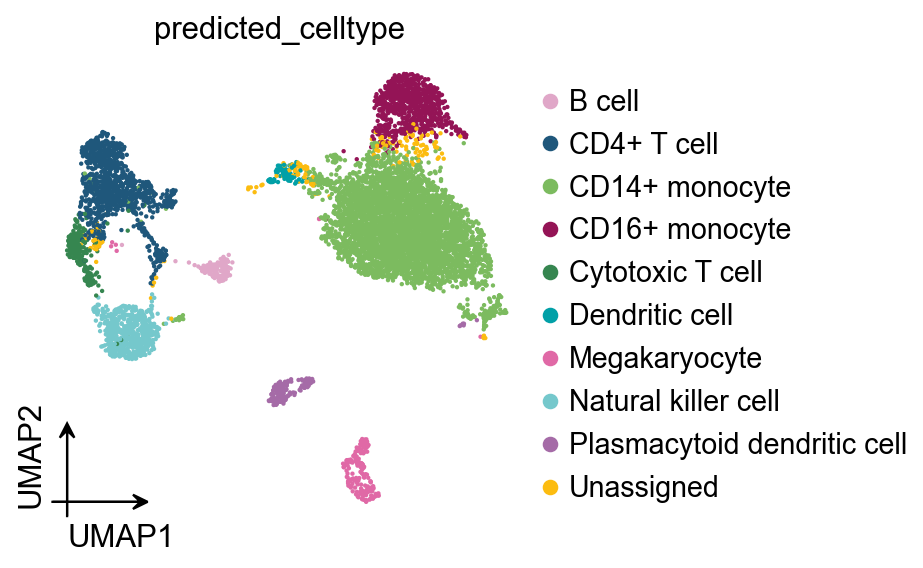

(<Figure size 800x80 with 1 Axes>, <Axes: >)

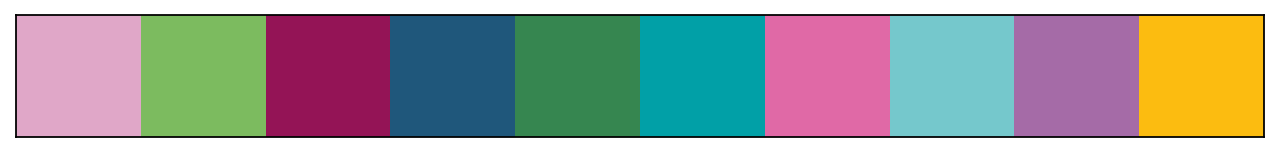

In [21]:
ov.pl.umap(
    adata,
    color=['predicted_celltype'],
    frameon='small',
    palette=color_mapping
)
ov.pl.palplot(list(color_mapping.values()))

### Spatial example: optimize only the mapping

We repeat the same procedure on true spatial coordinates (`sdata.obsm['spatial']`), where neighborhood relationships correspond to physical proximity in tissue.


In [30]:
# Get optimized color-cluster assignment with Spaco
spalette_default = [i[:7] for i in sdata.uns['celltype_mapped_refined_colors']].copy()
scolor_mapping = spaco.colorize(
    cell_coordinates=sdata.obsm['spatial'],
    cell_labels=sdata.obs['celltype_mapped_refined'],
    colorblind_type="none",
    radius=0.05, # radius is related to the physical scaling of .obsm['spatial']
    n_neighbors=30,
    palette=spalette_default, # if `palette` is specified, the `colorize` function only refines the assignment.
)
scolor_mapping

|-----> Calculating cluster distance graph...
|-----------> Calculating cell neighborhood...
|-----------> Filtering out neighborhood outliers...
|-----------> Calculating cluster interlacement score...
|-----------> Constructing cluster interlacement graph...
|-----> Calculating color distance graph...
|-----------> Calculating color perceptual distance...
|-----------> Constructing color distance graph...
|-----------> Difference of the most similar pair in the palette is 40.78
|-----> Optimizing color mapping...


{'Allantois': '#a499cc',
 'Anterior somitic tissues': '#9f987f',
 'Cardiomyocytes': '#e0a7c8',
 'Cranial mesoderm': '#5e4d9a',
 'Definitive endoderm': '#e069a6',
 'Dermomyotome': '#e0dfed',
 'Endothelium': '#1f577b',
 'Erythroid': '#75c8cc',
 'Forebrain/Midbrain/Hindbrain': '#eaefc5',
 'Gut tube': '#f0d7bc',
 'Haematoendothelial progenitors': '#fcbc10',
 'Intermediate mesoderm': '#866017',
 'Lateral plate mesoderm': '#f0eef0',
 'Low quality': '#941456',
 'Mixed mesenchymal mesoderm': '#368650',
 'NMP': '#d5b26c',
 'Neural crest': '#78c2ed',
 'Presomitic mesoderm': '#7cbb5f',
 'Sclerotome': '#a56ba7',
 'Spinal cord': '#01a0a7',
 'Splanchnic mesoderm': '#279ad7',
 'Surface ectoderm': '#ef7b77'}

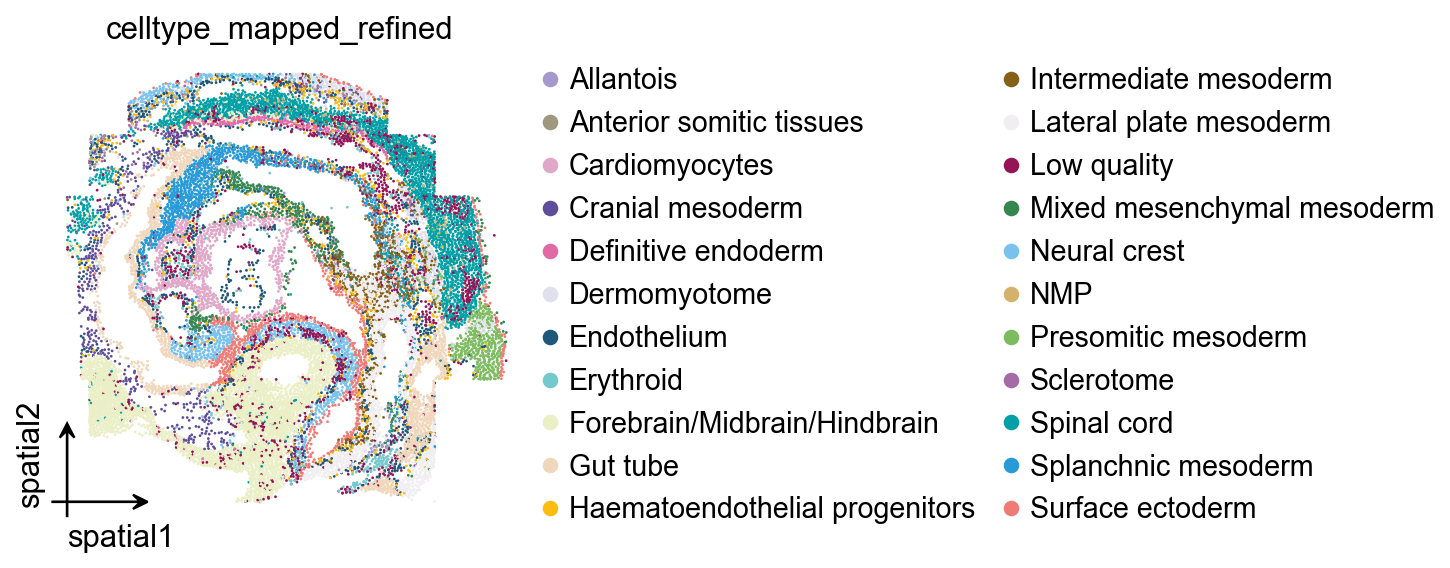

(<Figure size 1760x80 with 1 Axes>, <Axes: >)

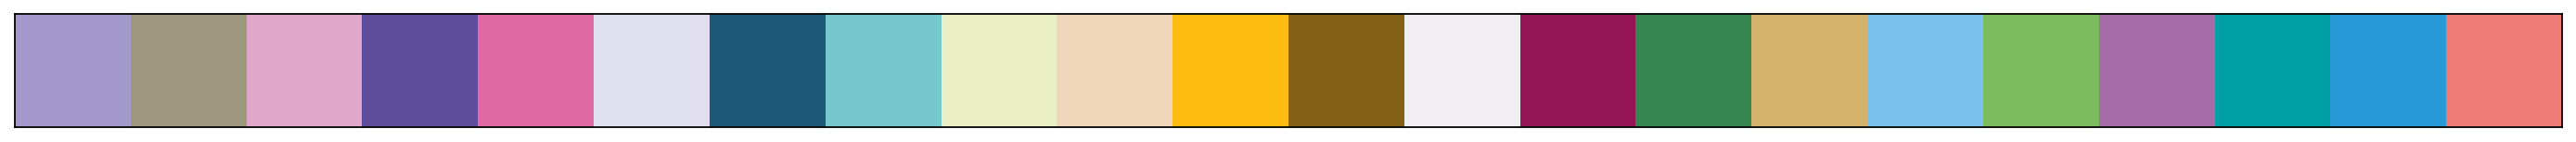

In [33]:
ov.pl.embedding(
    sdata,
    basis='spatial',
    color=['celltype_mapped_refined'],
    frameon='small',
    palette=scolor_mapping
)
ov.pl.palplot(list(scolor_mapping.values()))

## 3) Automatic colorization (CI-graph guided)

If you do *not* provide a palette, Spaco can generate one automatically by embedding the CI-graph into color space:

- Compute DOI and CI-graph from labels + coordinates (kNN + dual-outlier-free refinement).
- Embed CI-graph vertices into a 3D space using UMAP and **rescale** the embedding into the perceptually uniform **CIELab** color space.
- To avoid overly dark/bright colors, the illuminant channel \(L\) is typically constrained (e.g., \(L\in[20,85]\) in the paper).
- Convert Lab → RGB hex and then optionally refine the final cluster-color assignment (graph matching step).

This mode is particularly useful when:
- You have **many** clusters (dozens to hundreds),
- Clusters are spatially intermixed, and
- You do not want to manually curate a large palette.


### UMAP: generate palette + mapping automatically

Here `spaco.colorize` infers both the palette (graph-guided) and the cluster→color mapping.


In [34]:
color_mapping = spaco.colorize(
    cell_coordinates=adata.obsm['X_umap'],
    cell_labels=adata.obs['predicted_celltype'],
    colorblind_type="none",
    radius=0.05, # radius is related to the physical scaling of .obsm['spatial']
    n_neighbors=30,
    #palette=palette_default, # if `palette` is specified, the `colorize` function only refines the assignment.
)

|-----> Calculating cluster distance graph...
|-----------> Calculating cell neighborhood...
|-----------> Filtering out neighborhood outliers...
|-----------> Calculating cluster interlacement score...
|-----------> Constructing cluster interlacement graph...
|-----> `palette` not provided.
|-----------> Auto-generating colors from CIE Lab colorspace...
|-----------------> Calculating cluster embedding...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


|-----------------> Rescaling embedding to CIE Lab colorspace...
|-----> Optimizing cluster color mapping...


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


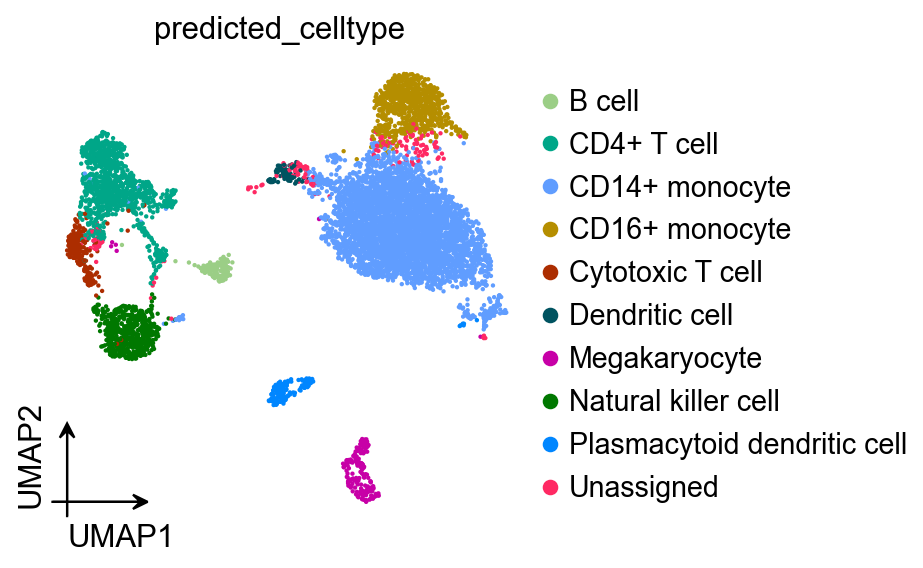

(<Figure size 800x80 with 1 Axes>, <Axes: >)

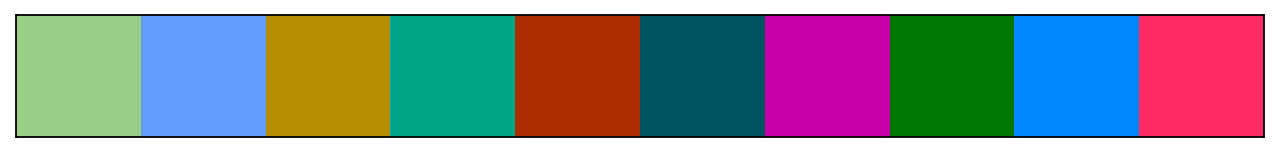

In [35]:
ov.pl.umap(
    adata,
    color=['predicted_celltype'],
    frameon='small',
    palette=color_mapping
)
ov.pl.palplot(list(color_mapping.values()))

### Spatial: generate palette + mapping automatically

Same as above, but using `obsm['spatial']` so the DOI reflects tissue neighborhoods.


In [36]:
scolor_mapping = spaco.colorize(
    cell_coordinates=sdata.obsm['spatial'],
    cell_labels=sdata.obs['celltype_mapped_refined'],
    colorblind_type="none",
    radius=0.05, # radius is related to the physical scaling of .obsm['spatial']
    n_neighbors=30,
    #palette=spalette_default, # if `palette` is specified, the `colorize` function only refines the assignment.
)

|-----> Calculating cluster distance graph...
|-----------> Calculating cell neighborhood...
|-----------> Filtering out neighborhood outliers...
|-----------> Calculating cluster interlacement score...
|-----------> Constructing cluster interlacement graph...
|-----> `palette` not provided.
|-----------> Auto-generating colors from CIE Lab colorspace...
|-----------------> Calculating cluster embedding...
|-----------------> Rescaling embedding to CIE Lab colorspace...
|-----> Optimizing cluster color mapping...


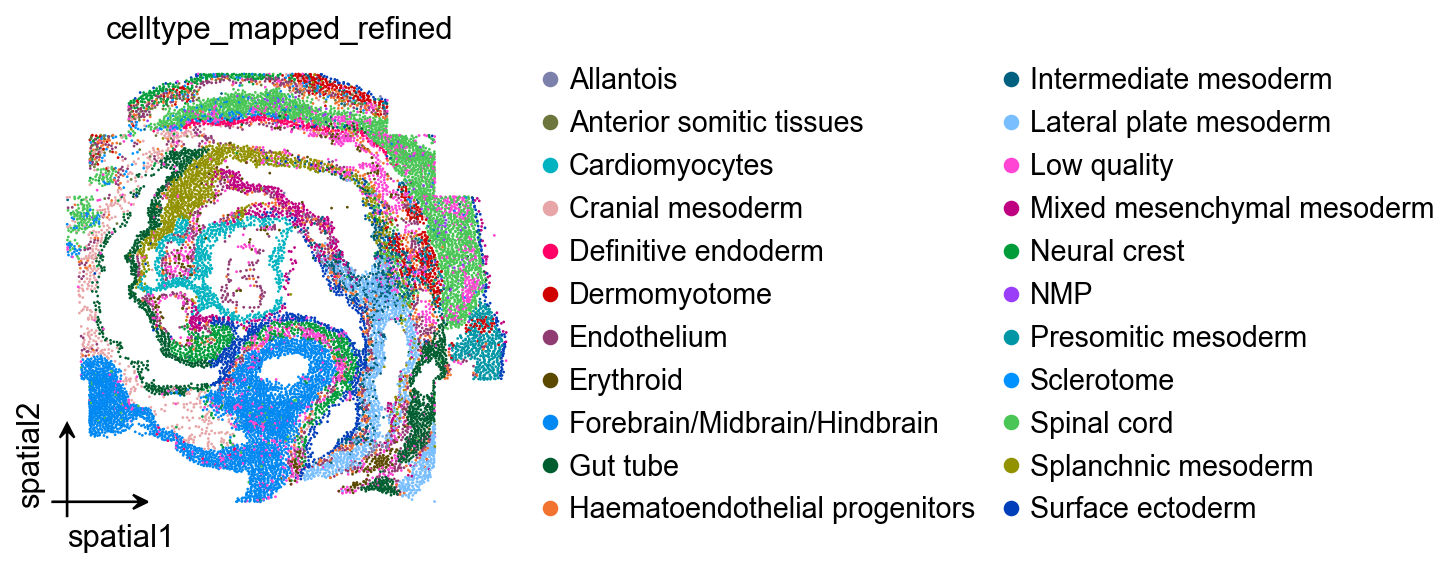

(<Figure size 1760x80 with 1 Axes>, <Axes: >)

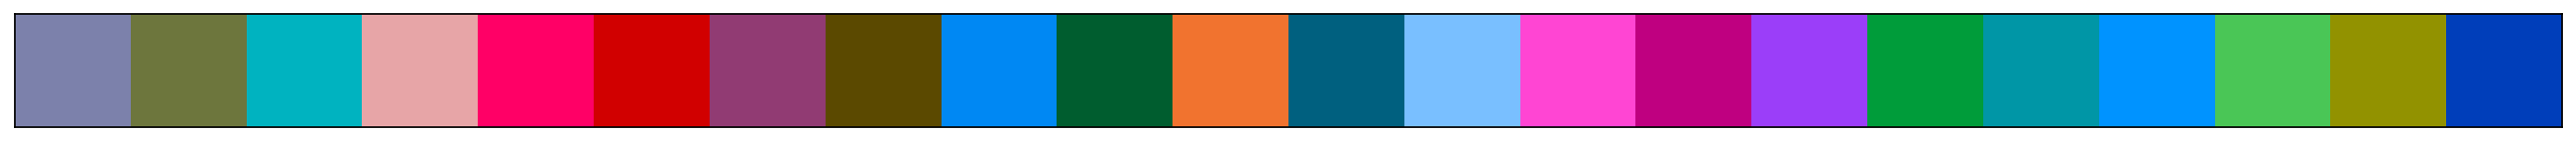

In [37]:
ov.pl.embedding(
    sdata,
    basis='spatial',
    color=['celltype_mapped_refined'],
    frameon='small',
    palette=scolor_mapping
)
ov.pl.palplot(list(scolor_mapping.values()))

## 4) Automatic colorization (Image guided)

For publication figures, you may want a coherent “theme” palette (e.g., from a cover image or an existing figure). Spaco supports **image-guided palette extraction**:

- Convert pixels to CIELab, bin colors, and filter extreme luminance / rare colors.
- Iteratively pick high-frequency colors while **penalizing** colors similar to already chosen ones.
- Refine the palette using farthest point sampling (FPS) to maximize separation.

After a palette is extracted, Spaco still performs the graph-based assignment so that adjacent/interlaced clusters get more contrasting colors.

> Tip: image-guided palettes are a great way to keep figures stylistically consistent across a paper or slide deck.


### Load a reference image

We load a demo image (from the Spaco vignette repository) and visualize it. In practice, you can replace this with your own figure/cover image.


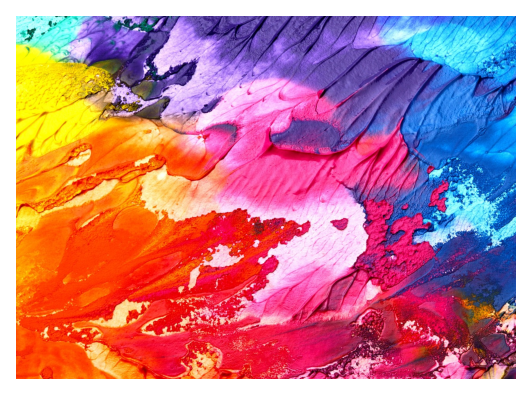

In [39]:
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/BrainStOrmics/Spaco_scripts/main/Vignette/data/colorful-2468874_1280.jpeg"

img = Image.open(BytesIO(requests.get(url).content)).convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.show()

### Apply image-guided palette to your data

Pass the image via `image_palette=img`. Spaco will extract a theme palette and then assign colors to clusters based on spatial (or embedding) neighborhoods.


In [40]:
color_mapping = spaco.colorize(
    cell_coordinates=adata.obsm['X_umap'],
    cell_labels=adata.obs['predicted_celltype'],
    colorblind_type="none",
    radius=0.05, # radius is related to the physical scaling of .obsm['spatial']
    n_neighbors=30,
    image_palette=img,
)

|-----> Calculating cluster distance graph...
|-----------> Calculating cell neighborhood...
|-----------> Filtering out neighborhood outliers...
|-----------> Calculating cluster interlacement score...
|-----------> Constructing cluster interlacement graph...
|-----> `palette` not provided.
|-----------> Using `image palette`...
|-----------> Drawing appropriate colors from provided image...
|-----------------> Extracting color bins...
|-----------------> Initiating palette...
|-----------------> Optimizing extracted palette...
|-----> Calculating color distance graph...
|-----------> Calculating color perceptual distance...
|-----------> Constructing color distance graph...
|-----------> Difference of the most similar pair in the palette is 175.51
|-----> Optimizing color mapping...


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


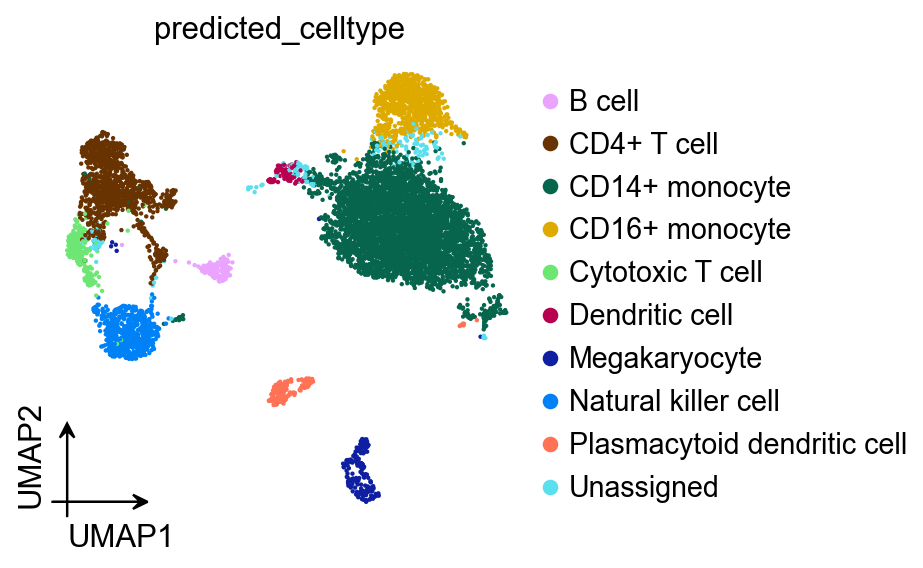

(<Figure size 800x80 with 1 Axes>, <Axes: >)

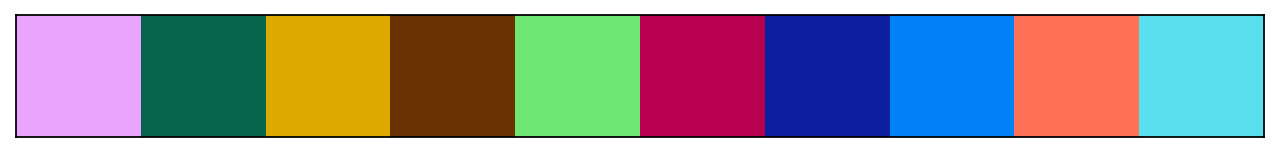

In [41]:
ov.pl.umap(
    adata,
    color=['predicted_celltype'],
    frameon='small',
    palette=color_mapping
)
ov.pl.palplot(list(color_mapping.values()))

In [42]:
scolor_mapping = spaco.colorize(
    cell_coordinates=sdata.obsm['spatial'],
    cell_labels=sdata.obs['celltype_mapped_refined'],
    colorblind_type="none",
    radius=0.05, # radius is related to the physical scaling of .obsm['spatial']
    n_neighbors=30,
    image_palette=img,
)

|-----> Calculating cluster distance graph...
|-----------> Calculating cell neighborhood...
|-----------> Filtering out neighborhood outliers...
|-----------> Calculating cluster interlacement score...
|-----------> Constructing cluster interlacement graph...
|-----> `palette` not provided.
|-----------> Using `image palette`...
|-----------> Drawing appropriate colors from provided image...
|-----------------> Extracting color bins...
|-----------------> Initiating palette...
|-----------------> Optimizing extracted palette...
|-----> Calculating color distance graph...
|-----------> Calculating color perceptual distance...
|-----------> Constructing color distance graph...
|-----------> Difference of the most similar pair in the palette is 96.62
|-----> Optimizing color mapping...


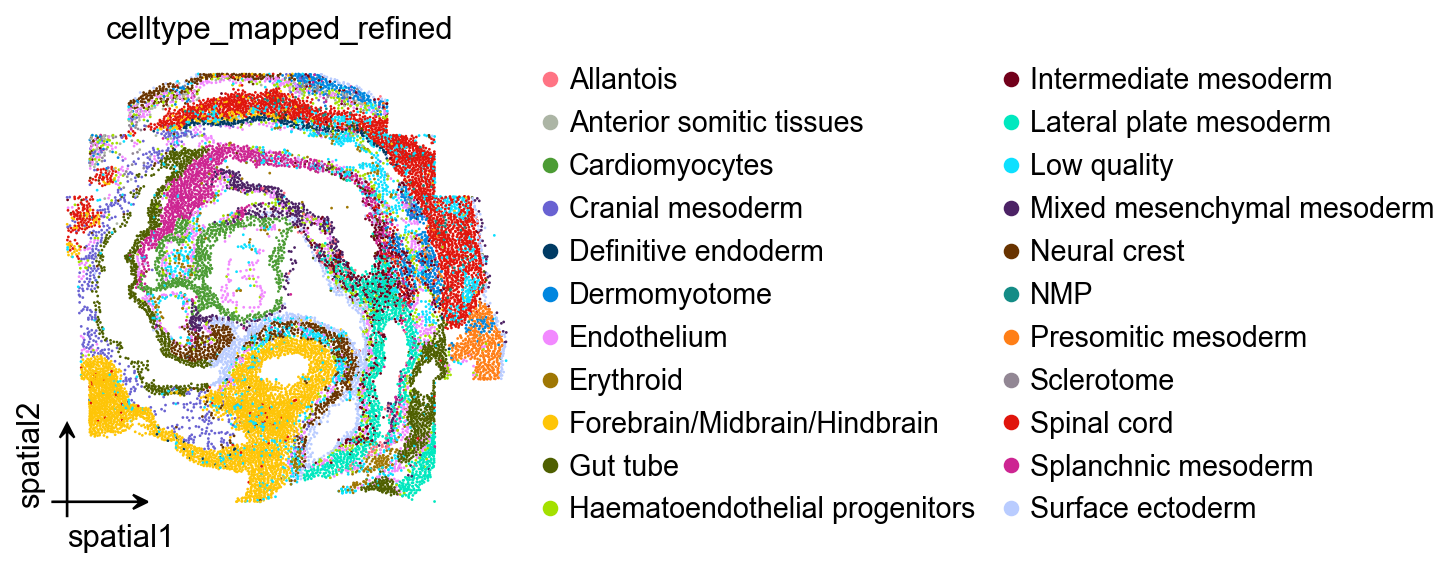

(<Figure size 1760x80 with 1 Axes>, <Axes: >)

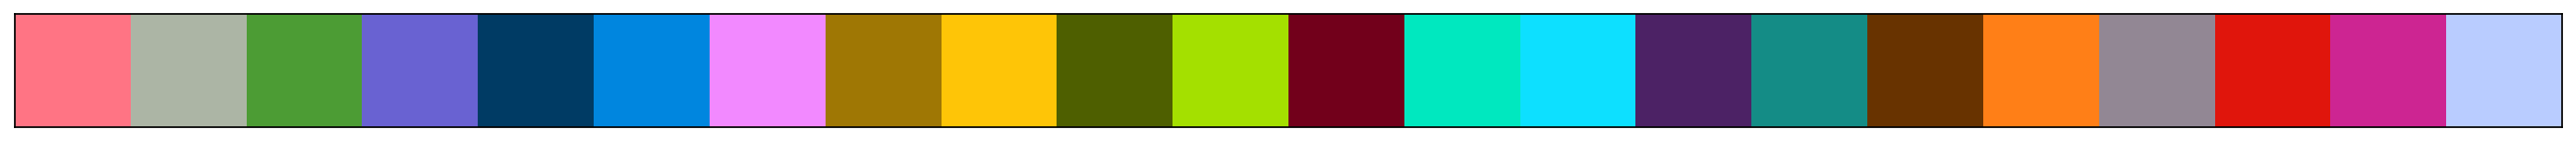

In [43]:
ov.pl.embedding(
    sdata,
    basis='spatial',
    color=['celltype_mapped_refined'],
    frameon='small',
    palette=scolor_mapping
)
ov.pl.palplot(list(scolor_mapping.values()))

---

## Summary / take-home checklist

- If you already like your colors but the plot is confusing → **keep palette, optimize assignment** (`palette=...`).
- If you have many clusters and want maximal discernibility → **CI-graph guided auto palette** (no `palette`).
- If you want a publication theme → **image-guided palette** (`image_palette=...`) + graph-based assignment.
- Always tune `radius` to match the scale of your coordinates (UMAP vs µm).

### Method reference
Spaco workflow: cluster interlacement modeling (DOI → CI-graph), adaptive palette selection (graph-guided or image-guided), and cluster-color assignment (CI-graph ↔ CD-graph matching).